# 🎓 *Del dato a la decisión: fundamentos de experimentación A/B*


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

---

🎯 *Objetivos académicos*

* Comprender los fundamentos de la verificación de hipótesis y su aplicación en negocios.
* Aplicar los criterios ICE y RICE para evaluar hipótesis y tomar decisiones informadas.

---


## 📌 *¿Por qué experimentar en negocios?*

En un entorno competitivo, las decisiones deben estar respaldadas por datos. El enfoque *data-driven* permite tomar decisiones informadas en lugar de actuar por intuición. Experimentar permite validar ideas, reducir riesgos y maximizar impacto con evidencia.

**Ejemplos de experimentos en negocios:**
* *Cualitativo*: entrevistas para conocer motivaciones de cancelación de suscripciones.
* *Cuantitativo*: test A/B para evaluar si una nueva oferta mejora la tasa de conversión.
* *Test A/A*: evaluar si la infraestructura de medición es confiable.

> *Una empresa que decide rediseñar su landing page debe medir el impacto del cambio, no solo lanzarlo a ciegas.*

---


🧪 *¿Qué hace buena una experimentación cuantitativa?*

Todo parte de una **hipótesis clara, medible y comprobable**. Si una hipótesis es ambigua o demasiado general, los resultados no ofrecerán conclusiones útiles.

**Ejemplo de hipótesis vaga:**
> Cambiar la página principal mejorará la experiencia del usuario.

**Ejemplo de hipótesis clara:**
> Si reducimos el tiempo de carga de la homepage en un 30%, la tasa de conversión aumentará al menos un 5%.

🔑 Criterios para una buena hipótesis:
* Clara y específica
* Medible con una métrica relevante
* Falsable
* Basada en observaciones o datos previos

---


📊 *¿Cómo decidir qué hipótesis probar?*

📋 *Framework ICE*

Fórmula:  
`ICE = (Impact × Confidence) / Effort`

📋 *Framework RICE*

Fórmula:  
`RICE = (Reach × Impact × Confidence) / Effort`

---


In [6]:
hipotesis = pd.DataFrame({
    'idea': ['Agregar CTA', 'Reducir pasos de compra', 'Cambiar color del botón'],
    'reach': [8, 6, 9],
    'impact': [7, 9, 4],
    'confidence': [8, 6, 5],
    'effort': [3, 7, 2]
})

hipotesis['ICE'] = (hipotesis['impact'] * hipotesis['confidence']) / hipotesis['effort']
hipotesis['RICE'] = (hipotesis['reach'] * hipotesis['impact'] * hipotesis['confidence']) / hipotesis['effort']

hipotesis.round().sort_values(by='RICE', ascending=False)

,idea,reach,impact,confidence,effort,ICE,RICE
0,Agregar CTA,8,7,8,3,19.0,149.0
2,Cambiar color del botón,9,4,5,2,10.0,90.0
1,Reducir pasos de compra,6,9,6,7,8.0,46.0


---

🔬 *Pruebas A/B: Diseño de un buen test*

Una prueba A/B compara dos versiones de algo para identificar cuál tiene mejor rendimiento en una métrica clave.

🧠 *Conceptos fundamentales*

📏 *Tamaño de muestra*

**Fórmula:**

$$

n = \frac{2 \cdot \left(Z_{\alpha/2} + Z_{\beta}\right)^2 \cdot p(1 - p)}{d^2}

$$

Donde:
- $Z_{\alpha/2}$: valor z para el nivel de significancia (ej. 1.96 para 95%)
- $Z_{\beta}$: valor z para la potencia deseada (ej. 0.84 para 80%)
- $p$: tasa de conversión estimada
- $d$: diferencia mínima detectable

⏱️ *Duración mínima*  
Debe cubrir ciclos naturales (días de semana y fines de semana). No se debe cortar la prueba antes del tiempo estimado.

⚠️ *Errores comunes*  
- **Tipo I (α)**: Falso positivo.
- **Tipo II (β)**: Falso negativo.

🧪 Ejercicio práctico: Simulación de errores tipo I, tipo II y potencia de prueba 

Queremos probar si una nueva versión de una página web (grupo B) mejora la tasa de conversión respecto a la versión actual (grupo A).

Simularemos múltiples experimentos donde:

- El grupo A siempre tiene una tasa de conversión del 10%.

- El grupo B puede tener la misma conversión (para ver errores tipo I) o una ligeramente mayor (para analizar potencia y errores tipo II).



In [ ]:
# Parámetros
# @title Number fields
p_control = 0.10        # tasa de conversión grupo A
p_test = 0.12           # @param {type:"slider", min:0.09, max:0.15, step:0.01}
n = 1000                # usuarios por grupo
num_experimentos = 1000
alpha = 0.05            # nivel de significancia

Proporción de rechazos (rechazar H0): 0.30


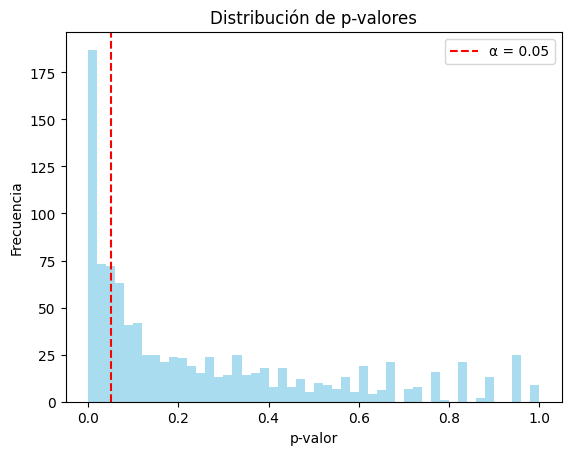

In [ ]:

np.random.seed(42)
p_values = []
rechazos = 0

for _ in range(num_experimentos):
    a = np.random.binomial(1, p_control, n)
    b = np.random.binomial(1, p_test, n)
    stat, p = ttest_ind(a, b)
    p_values.append(p)
    if p < alpha:
        rechazos += 1

# Resultados
print(f"Proporción de rechazos (rechazar H0): {rechazos / num_experimentos:.2f}")

# Visualización
plt.hist(p_values, bins=50, alpha=0.7, color='skyblue')
plt.axvline(x=alpha, color='red', linestyle='--', label='α = 0.05')
plt.title('Distribución de p-valores')
plt.xlabel('p-valor')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

🔢 *Comparaciones múltiples: A/B/n*

Al probar más de 2 versiones aumenta la probabilidad de falsos positivos. Por eso se ajustan los p-valores con:

* **Bonferroni**: α' = α / n → Muy conservador.
* **Holm**: Ajuste progresivo. Menos conservador.
* **Sidak**: Asume independencia.
  `α' = 1 - (1 - α)^(1/n)`

> *La idea central es proteger la tasa de error cuando se hacen muchas comparaciones.*

---

🚫 *¿Cuándo no hacer un test A/B?*

* Poca muestra (no alcanza potencia).
* Hipótesis mal definida.
* Entorno incontrolable.
* Hay evidencia previa sólida.